In [110]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats

In [111]:
sales = pd.read_csv('../../Datasets/fromclass/AusApparalSales4thQrt2020.csv')
df = pd.DataFrame(sales )
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

# plt.figure(figsize=(10,5))
# state_sales.plot(kind='bar', color='skyblue')
# plt.title("Total Sales by State - Q4 2020")
# plt.xlabel("State")
# plt.ylabel("Total Sales ($)")
# plt.show()

# Based on Q4 2020 apparel sales data, Victoria (VIC) generated the highest total sales, followed by New South Wales (NSW) and South Australia (SA).

# The bottom-performing states were Queensland (QLD), Tasmania (TAS), Northern Territory (NT), and Western Australia (WA) — each contributing significantly below the national average.

# Insights:
# 	•	VIC and NSW together account for over 50% of total national sales.
# 	•	SA shows potential for further investment — mid-level performance with room for growth.
# 	•	QLD, TAS, NT, and WA may require regional marketing strategies to boost awareness and sales.

In [112]:
df.shape

df['Date'] = pd.to_datetime(df['Date'])

In [113]:

categorical = df.select_dtypes(include=['object']).columns
categorical
df['State'].unique()
df


,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,8,20000
1,2020-10-01,Morning,WA,Men,8,20000
2,2020-10-01,Morning,WA,Women,4,10000
3,2020-10-01,Morning,WA,Seniors,15,37500
4,2020-10-01,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,2020-12-30,Afternoon,TAS,Seniors,14,35000
7556,2020-12-30,Evening,TAS,Kids,15,37500
7557,2020-12-30,Evening,TAS,Men,15,37500
7558,2020-12-30,Evening,TAS,Women,11,27500


In [114]:
for cols in df.columns:
  if cols in categorical:
    df[cols]= df[cols].str.strip()
    print(cols)
    print(df[cols].unique())
    print(df[cols].value_counts())
    print('......................')

Time
['Morning' 'Afternoon' 'Evening']
Time
Morning      2520
Afternoon    2520
Evening      2520
Name: count, dtype: int64
......................
State
['WA' 'NT' 'SA' 'VIC' 'QLD' 'NSW' 'TAS']
State
WA     1080
NT     1080
SA     1080
VIC    1080
QLD    1080
NSW    1080
TAS    1080
Name: count, dtype: int64
......................
Group
['Kids' 'Men' 'Women' 'Seniors']
Group
Kids       1890
Men        1890
Women      1890
Seniors    1890
Name: count, dtype: int64
......................


In [156]:
# sns.countplot(x=df['State'], hue = df['State'], legend=False)
# sns.histplot(x=df['Sales'])
# sns.histplot(x=df['Unit'], y=df['State'])


<Axes: xlabel='State', ylabel='Unit'>

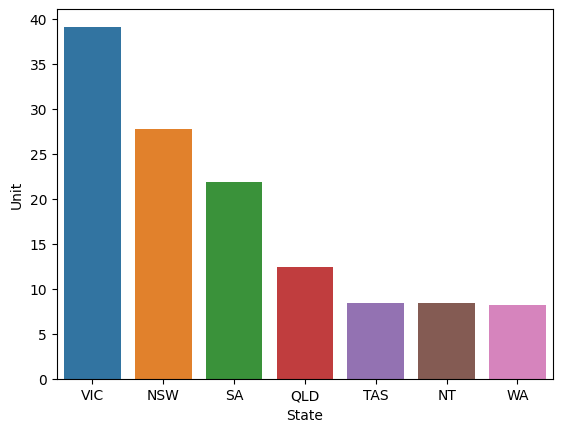

In [163]:
average=df.groupby('State')['Unit'].mean().sort_values(ascending=False)
df.groupby('State')['Sales'].mean().sort_values(ascending=False)
df.groupby('State')['Sales'].sum().sort_values(ascending=False)

sns.barplot(x=average.index, y=average, hue=average.index, legend=False)

<Axes: xlabel='State', ylabel='Sales'>

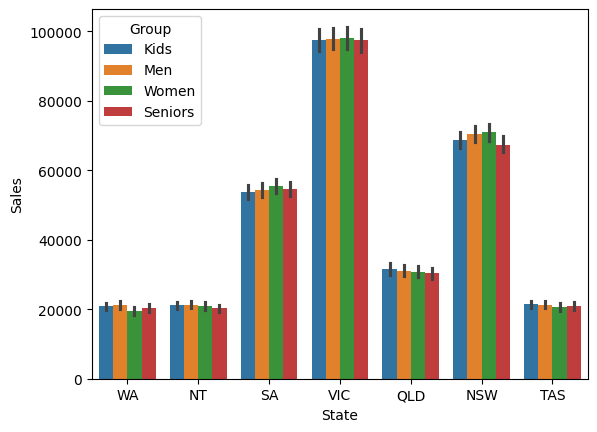

In [168]:
sns.barplot(data=df, x='State', y='Sales', hue='Group')


In [ ]:
group = df.groupby(['State', 'Group'])[['Sales', 'Unit']].sum().round(0).reset_index().sort_values(by=['State', 'Sales'], ascending=False)
group.reset_index(drop=True)


,State,Group,Sales,Unit
0,WA,Men,5752500,2301
1,WA,Kids,5625000,2250
2,WA,Seniors,5512500,2205
3,WA,Women,5262500,2105
4,VIC,Women,26482500,10593
5,VIC,Men,26407500,10563
6,VIC,Kids,26360000,10544
7,VIC,Seniors,26315000,10526
8,TAS,Kids,5775000,2310
9,TAS,Men,5757500,2303
